In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.signal import butter, filtfilt, find_peaks, hilbert
from scipy.stats import ttest_ind
from scipy import stats
import warnings
import re
import matplotlib.cm as cm
import statsmodels.formula.api as smf

In [3]:
# ====== PARAMETRES ======
dossier = "Coda_data"

fichiers_S01 = [
    "Gr4_S01_S1_20250011_017.txt",
    "Gr4_S01_S1_20250011_018.txt",
    "Gr4_S01_S1_20250011_019.txt",
    "Gr4_S01_S1_20250011_020.txt",
    "Gr4_S01_S2_20250011_021.txt",
    "Gr4_S01_S2_20250011_022.txt",
    "Gr4_S01_S2_20250011_023.txt",
    "Gr4_S01_S2_20250011_024.txt",
    "Gr4_S01_S3_20250011_025.txt",
    "Gr4_S01_S3_20250011_026.txt",
    "Gr4_S01_S3_20250011_027.txt",
    "Gr4_S01_S3_20250011_028.txt",
    "Gr4_S01_S4_20250011_029.txt",
    "Gr4_S01_S4_20250011_030.txt",
    "Gr4_S01_S4_20250011_031.txt",
    "Gr4_S01_S4_20250011_032.txt",
]

# ====== FILTRE PASSE-BAS ======
fs = 200
fc = 5
b, a = butter(4, fc/(fs/2), btype='low')
h = 1/fs  # pas de temps = 0.005 s

# ====== DATAFRAME FINAL ======
resultats = []

for f in fichiers_S01:
    chemin = os.path.join(dossier, f)

    df = pd.read_csv(chemin, sep="\t", header=2)
    df.columns = df.columns.str.strip()
    df = df.replace("NaN", np.nan)

    colonnes_a_supprimer = [c for c in df.columns if ".V" in c or c.strip() == ""]
    df = df.drop(columns=colonnes_a_supprimer, errors="ignore")

    time_col = "Time" if "Time" in df.columns else "Time (s)"

    pattern = r"Marker 0[5-8]\.[XYZ]"
    colonnes_markers = [c for c in df.columns if re.search(pattern, c)]
    df = df[[time_col] + colonnes_markers]
    df = df.apply(pd.to_numeric, errors="coerce")

    # ====== CENTRE RECTANGLE ======
    cx = ((df["Marker 05.X"] + df["Marker 06.X"])/2 +
          (df["Marker 07.X"] + df["Marker 08.X"])/2)/2

    cy = ((df["Marker 05.Y"] + df["Marker 06.Y"])/2 +
          (df["Marker 07.Y"] + df["Marker 08.Y"])/2)/2

    cz = ((df["Marker 05.Z"] + df["Marker 06.Z"])/2 +
          (df["Marker 07.Z"] + df["Marker 08.Z"])/2)/2


    # ====== INTERPOLATION NaN ======
    for signal in [cx, cy, cz]:
        nan_idx = np.isnan(signal)
        if np.any(nan_idx):
            signal[nan_idx] = np.interp(
                np.flatnonzero(nan_idx),
                np.flatnonzero(~nan_idx),
                signal[~nan_idx]
            )

    # ====== FILTRAGE ======
    cx = filtfilt(b, a, cx)
    cy = filtfilt(b, a, cy)
    cz = filtfilt(b, a, cz)

    # ====== NOM PROPRE ======
    m = re.search(r"Gr4_(S\d+)_(S\d+)_\d+_(\d+)\.txt$", f)
    if m:
        s_part = m.group(1)
        l_part = m.group(2)
        num = str(int(m.group(3)))
        col_base = f"{s_part}_{l_part}_{num}"
    else:
        col_base = f.replace(".txt","")

    # ====== DATAFRAME POSITION (comme avant) ======
    df_res = pd.DataFrame({
        "Time": df[time_col],
        f"{col_base}_X": cx,
        f"{col_base}_Y": cy,
        f"{col_base}_Z": cz
    })

    resultats.append(df_res)

# ====== FUSION DATAFRAME POSITION ======
finus_1 = resultats[0]
for df in resultats[1:]:
    finus_1 = finus_1.merge(df, on="Time")

# ====== AFFICHAGE ======
print("✅ Fusion terminée")

print("\nColonnes df_final :")
print(finus_1.columns.tolist())


✅ Fusion terminée

Colonnes df_final :
['Time', 'S01_S1_17_X', 'S01_S1_17_Y', 'S01_S1_17_Z', 'S01_S1_18_X', 'S01_S1_18_Y', 'S01_S1_18_Z', 'S01_S1_19_X', 'S01_S1_19_Y', 'S01_S1_19_Z', 'S01_S1_20_X', 'S01_S1_20_Y', 'S01_S1_20_Z', 'S01_S2_21_X', 'S01_S2_21_Y', 'S01_S2_21_Z', 'S01_S2_22_X', 'S01_S2_22_Y', 'S01_S2_22_Z', 'S01_S2_23_X', 'S01_S2_23_Y', 'S01_S2_23_Z', 'S01_S2_24_X', 'S01_S2_24_Y', 'S01_S2_24_Z', 'S01_S3_25_X', 'S01_S3_25_Y', 'S01_S3_25_Z', 'S01_S3_26_X', 'S01_S3_26_Y', 'S01_S3_26_Z', 'S01_S3_27_X', 'S01_S3_27_Y', 'S01_S3_27_Z', 'S01_S3_28_X', 'S01_S3_28_Y', 'S01_S3_28_Z', 'S01_S4_29_X', 'S01_S4_29_Y', 'S01_S4_29_Z', 'S01_S4_30_X', 'S01_S4_30_Y', 'S01_S4_30_Z', 'S01_S4_31_X', 'S01_S4_31_Y', 'S01_S4_31_Z', 'S01_S4_32_X', 'S01_S4_32_Y', 'S01_S4_32_Z']


In [4]:
# ====== PARAMETRES ======
dossier = "Coda_data"

fichiers_S01 = [
    "Gr4_S02_S1_20250011_015.txt",
    "Gr4_S02_S1_20250011_016.txt",
    "Gr4_S02_S1_20250011_017.txt",
    "Gr4_S02_S1_20250011_018.txt",
    "Gr4_S02_S2_20250011_019.txt",
    "Gr4_S02_S2_20250011_020.txt",
    "Gr4_S02_S2_20250011_021.txt",
    "Gr4_S02_S2_20250011_022.txt",
    "Gr4_S02_S3_20250011_023.txt",
    "Gr4_S02_S3_20250011_024.txt",
    "Gr4_S02_S3_20250011_025.txt",
    "Gr4_S02_S3_20250011_026.txt",
    "Gr4_S02_S4_20250011_027.txt",
    "Gr4_S02_S4_20250011_028.txt",
    "Gr4_S02_S4_20250011_029.txt",
    "Gr4_S02_S4_20250011_030.txt",
]

# ====== FILTRE PASSE-BAS ======
fs = 200
fc = 5
b, a = butter(4, fc/(fs/2), btype='low')
h = 1/fs  # pas de temps = 0.005 s

# ====== DATAFRAME FINAL ======
resultats = []

for f in fichiers_S01:
    chemin = os.path.join(dossier, f)

    df = pd.read_csv(chemin, sep="\t", header=2)
    df.columns = df.columns.str.strip()
    df = df.replace("NaN", np.nan)

    colonnes_a_supprimer = [c for c in df.columns if ".V" in c or c.strip() == ""]
    df = df.drop(columns=colonnes_a_supprimer, errors="ignore")

    time_col = "Time" if "Time" in df.columns else "Time (s)"

    pattern = r"Marker 0[5-8]\.[XYZ]"
    colonnes_markers = [c for c in df.columns if re.search(pattern, c)]
    df = df[[time_col] + colonnes_markers]
    df = df.apply(pd.to_numeric, errors="coerce")

    # ====== CENTRE RECTANGLE ======
    cx = ((df["Marker 05.X"] + df["Marker 06.X"])/2 +
          (df["Marker 07.X"] + df["Marker 08.X"])/2)/2

    cy = ((df["Marker 05.Y"] + df["Marker 06.Y"])/2 +
          (df["Marker 07.Y"] + df["Marker 08.Y"])/2)/2

    cz = ((df["Marker 05.Z"] + df["Marker 06.Z"])/2 +
          (df["Marker 07.Z"] + df["Marker 08.Z"])/2)/2


    # ====== INTERPOLATION NaN ======
    for signal in [cx, cy, cz]:
        nan_idx = np.isnan(signal)
        if np.any(nan_idx):
            signal[nan_idx] = np.interp(
                np.flatnonzero(nan_idx),
                np.flatnonzero(~nan_idx),
                signal[~nan_idx]
            )

    # ====== FILTRAGE ======
    cx = filtfilt(b, a, cx)
    cy = filtfilt(b, a, cy)
    cz = filtfilt(b, a, cz)

    # ====== NOM PROPRE ======
    m = re.search(r"Gr4_(S\d+)_(S\d+)_\d+_(\d+)\.txt$", f)
    if m:
        s_part = m.group(1)
        l_part = m.group(2)
        num = str(int(m.group(3)))
        col_base = f"{s_part}_{l_part}_{num}"
    else:
        col_base = f.replace(".txt","")

    # ====== DATAFRAME POSITION (comme avant) ======
    df_res = pd.DataFrame({
        "Time": df[time_col],
        f"{col_base}_X": cx,
        f"{col_base}_Y": cy,
        f"{col_base}_Z": cz
    })

    resultats.append(df_res)


# ====== FUSION DATAFRAME POSITION ======
finus_2 = resultats[0]
for df in resultats[1:]:
    finus_2 = finus_2.merge(df, on="Time")

# ====== AFFICHAGE ======
print("✅ Fusion terminée")

print("\nColonnes df_final :")
print(finus_2.columns.tolist())


✅ Fusion terminée

Colonnes df_final :
['Time', 'S02_S1_15_X', 'S02_S1_15_Y', 'S02_S1_15_Z', 'S02_S1_16_X', 'S02_S1_16_Y', 'S02_S1_16_Z', 'S02_S1_17_X', 'S02_S1_17_Y', 'S02_S1_17_Z', 'S02_S1_18_X', 'S02_S1_18_Y', 'S02_S1_18_Z', 'S02_S2_19_X', 'S02_S2_19_Y', 'S02_S2_19_Z', 'S02_S2_20_X', 'S02_S2_20_Y', 'S02_S2_20_Z', 'S02_S2_21_X', 'S02_S2_21_Y', 'S02_S2_21_Z', 'S02_S2_22_X', 'S02_S2_22_Y', 'S02_S2_22_Z', 'S02_S3_23_X', 'S02_S3_23_Y', 'S02_S3_23_Z', 'S02_S3_24_X', 'S02_S3_24_Y', 'S02_S3_24_Z', 'S02_S3_25_X', 'S02_S3_25_Y', 'S02_S3_25_Z', 'S02_S3_26_X', 'S02_S3_26_Y', 'S02_S3_26_Z', 'S02_S4_27_X', 'S02_S4_27_Y', 'S02_S4_27_Z', 'S02_S4_28_X', 'S02_S4_28_Y', 'S02_S4_28_Z', 'S02_S4_29_X', 'S02_S4_29_Y', 'S02_S4_29_Z', 'S02_S4_30_X', 'S02_S4_30_Y', 'S02_S4_30_Z']


In [5]:
# ====== PARAMETRES ======
dossier = "Coda_data"

fichiers_S01 = [
    "Gr4_S03_S1_20250011_013.txt",
    "Gr4_S03_S1_20250011_014.txt",
    "Gr4_S03_S1_20250011_015.txt",
    "Gr4_S03_S2_20250011_016.txt",
    "Gr4_S03_S2_20250011_017.txt",
    "Gr4_S03_S2_20250011_018.txt",
]

# ====== FILTRE PASSE-BAS ======
fs = 200
fc = 5
b, a = butter(4, fc/(fs/2), btype='low')
h = 1/fs  # pas de temps = 0.005 s

# ====== DATAFRAME FINAL ======
resultats = []


for f in fichiers_S01:
    chemin = os.path.join(dossier, f)

    df = pd.read_csv(chemin, sep="\t", header=2)
    df.columns = df.columns.str.strip()
    df = df.replace("NaN", np.nan)

    colonnes_a_supprimer = [c for c in df.columns if ".V" in c or c.strip() == ""]
    df = df.drop(columns=colonnes_a_supprimer, errors="ignore")

    time_col = "Time" if "Time" in df.columns else "Time (s)"

    pattern = r"Marker (1[7-9]|20)\.[XYZ]"
    
    colonnes_markers = [c for c in df.columns if re.search(pattern, c)]
    df = df[[time_col] + colonnes_markers]
    df = df.apply(pd.to_numeric, errors="coerce")

    # ====== CENTRE RECTANGLE ======
    cx = ((df["Marker 17.X"] + df["Marker 18.X"])/2 +
          (df["Marker 19.X"] + df["Marker 20.X"])/2)/2

    cy = ((df["Marker 17.Y"] + df["Marker 18.Y"])/2 +
          (df["Marker 19.Y"] + df["Marker 20.Y"])/2)/2

    cz = ((df["Marker 17.Z"] + df["Marker 18.Z"])/2 +
          (df["Marker 19.Z"] + df["Marker 20.Z"])/2)/2

    # ====== INTERPOLATION NaN ======
    for signal in [cx, cy, cz]:
        nan_idx = np.isnan(signal)
        if np.any(nan_idx):
            signal[nan_idx] = np.interp(
                np.flatnonzero(nan_idx),
                np.flatnonzero(~nan_idx),
                signal[~nan_idx]
            )

    # ====== FILTRAGE ======
    cx = filtfilt(b, a, cx)
    cy = filtfilt(b, a, cy)
    cz = filtfilt(b, a, cz)

    # ====== NOM PROPRE ======
    m = re.search(r"Gr4_(S\d+)_(S\d+)_\d+_(\d+)\.txt$", f)
    if m:
        s_part = m.group(1)
        l_part = m.group(2)
        num = str(int(m.group(3)))
        col_base = f"{s_part}_{l_part}_{num}"
    else:
        col_base = f.replace(".txt","")

    # ====== DATAFRAME POSITION (comme avant) ======
    df_res = pd.DataFrame({
        "Time": df[time_col],
        f"{col_base}_X": cx,
        f"{col_base}_Y": cy,
        f"{col_base}_Z": cz
    })

    resultats.append(df_res)

# ====== FUSION DATAFRAME POSITION ======
df_final_1 = resultats[0]
for df in resultats[1:]:
    df_final_1 = df_final_1.merge(df, on="Time")

In [7]:
# ====== PARAMETRES ======
dossier = "Coda_data"

fichiers_S01 = [
    "Gr4_S03_S3_20250011_001.txt",
    "Gr4_S03_S3_20250011_002.txt",
    "Gr4_S03_S3_20250011_003.txt",
    "Gr4_S03_S4_20250011_004.txt",
    "Gr4_S03_S4_20250011_005.txt",
    "Gr4_S03_S4_20250011_006.txt",
]

# ====== FILTRE PASSE-BAS ======
fs = 200
fc = 5
b, a = butter(4, fc/(fs/2), btype='low')
h = 1/fs  # pas de temps = 0.005 s

# ====== DATAFRAME FINAL ======
resultats = []

for f in fichiers_S01:
    chemin = os.path.join(dossier, f)

    df = pd.read_csv(chemin, sep="\t", header=2)
    df.columns = df.columns.str.strip()
    df = df.replace("NaN", np.nan)

    colonnes_a_supprimer = [c for c in df.columns if ".V" in c or c.strip() == ""]
    df = df.drop(columns=colonnes_a_supprimer, errors="ignore")

    time_col = "Time" if "Time" in df.columns else "Time (s)"

    pattern = r"Marker (1[7-9]|20)\.[XYZ]"
    
    colonnes_markers = [c for c in df.columns if re.search(pattern, c)]
    df = df[[time_col] + colonnes_markers]
    df = df.apply(pd.to_numeric, errors="coerce")

    # ====== CENTRE RECTANGLE ======
    cx = ((df["Marker 17.X"] + df["Marker 18.X"])/2 +
          (df["Marker 19.X"] + df["Marker 20.X"])/2)/2

    cy = ((df["Marker 17.Y"] + df["Marker 18.Y"])/2 +
          (df["Marker 19.Y"] + df["Marker 20.Y"])/2)/2

    cz = ((df["Marker 17.Z"] + df["Marker 18.Z"])/2 +
          (df["Marker 19.Z"] + df["Marker 20.Z"])/2)/2


    # ====== INTERPOLATION NaN ======
    for signal in [cx, cy, cz]:
        nan_idx = np.isnan(signal)
        if np.any(nan_idx):
            signal[nan_idx] = np.interp(
                np.flatnonzero(nan_idx),
                np.flatnonzero(~nan_idx),
                signal[~nan_idx]
            )

    # ====== FILTRAGE ======
    cx = filtfilt(b, a, cx)
    cy = filtfilt(b, a, cy)
    cz = filtfilt(b, a, cz)


    # ====== NOM PROPRE ======
    m = re.search(r"Gr4_(S\d+)_(S\d+)_\d+_(\d+)\.txt$", f)
    if m:
        s_part = m.group(1)
        l_part = m.group(2)
        num = str(int(m.group(3)))
        col_base = f"{s_part}_{l_part}_{num}"
    else:
        col_base = f.replace(".txt","")

    # ====== DATAFRAME POSITION (comme avant) ======
    df_res = pd.DataFrame({
        "Time": df[time_col],
        f"{col_base}_X": cx,
        f"{col_base}_Y": cy,
        f"{col_base}_Z": cz
    })

    resultats.append(df_res)

# ====== FUSION DATAFRAME POSITION ======
df_final_2 = resultats[0]
for df in resultats[1:]:
    df_final_2 = df_final_2.merge(df, on="Time")

#Fix des temps :
df_final_2['Time'] = df_final_2['Time'] - 0.003

In [8]:
# Conserver la colonne Time du premier df, et ajouter les colonnes du deuxième df (sauf Time)
finus_3= pd.concat([df_final_2, df_final_1.drop(columns=['Time'])], axis=1)

In [9]:
# ====== PARAMETRES ======
dossier = "Coda_data"

fichiers_S01 = [
    "Gr4_S04_S1_20250011_013.txt",
    "Gr4_S04_S1_20250011_014.txt",
    "Gr4_S04_S1_20250011_015.txt",
    "Gr4_S04_S2_20250011_016.txt",
    "Gr4_S04_S2_20250011_017.txt",
    "Gr4_S04_S2_20250011_018.txt",
    "Gr4_S04_S3_20250011_019.txt",
    "Gr4_S04_S3_20250011_020.txt",
    "Gr4_S04_S3_20250011_021.txt",
    "Gr4_S04_S4_20250011_022.txt",
    "Gr4_S04_S4_20250011_023.txt",
    "Gr4_S04_S4_20250011_024.txt",
]

# ====== FILTRE PASSE-BAS ======
fs = 200
fc = 5
b, a = butter(4, fc/(fs/2), btype='low')
h = 1/fs  # pas de temps = 0.005 s

# ====== DATAFRAME FINAL ======
resultats = []

for f in fichiers_S01:
    chemin = os.path.join(dossier, f)

    df = pd.read_csv(chemin, sep="\t", header=2)
    df.columns = df.columns.str.strip()
    df = df.replace("NaN", np.nan)

    colonnes_a_supprimer = [c for c in df.columns if ".V" in c or c.strip() == ""]
    df = df.drop(columns=colonnes_a_supprimer, errors="ignore")

    time_col = "Time" if "Time" in df.columns else "Time (s)"

    pattern = r"Marker (1[7-9]|20)\.[XYZ]"
    
    colonnes_markers = [c for c in df.columns if re.search(pattern, c)]
    df = df[[time_col] + colonnes_markers]
    df = df.apply(pd.to_numeric, errors="coerce")

    # ====== CENTRE RECTANGLE ======
    cx = ((df["Marker 17.X"] + df["Marker 18.X"])/2 +
          (df["Marker 19.X"] + df["Marker 20.X"])/2)/2

    cy = ((df["Marker 17.Y"] + df["Marker 18.Y"])/2 +
          (df["Marker 19.Y"] + df["Marker 20.Y"])/2)/2

    cz = ((df["Marker 17.Z"] + df["Marker 18.Z"])/2 +
          (df["Marker 19.Z"] + df["Marker 20.Z"])/2)/2


    # ====== INTERPOLATION NaN ======
    for signal in [cx, cy, cz]:
        nan_idx = np.isnan(signal)
        if np.any(nan_idx):
            signal[nan_idx] = np.interp(
                np.flatnonzero(nan_idx),
                np.flatnonzero(~nan_idx),
                signal[~nan_idx]
            )

    # ====== FILTRAGE ======
    cx = filtfilt(b, a, cx)
    cy = filtfilt(b, a, cy)
    cz = filtfilt(b, a, cz)

    # ====== NOM PROPRE ======
    m = re.search(r"Gr4_(S\d+)_(S\d+)_\d+_(\d+)\.txt$", f)
    if m:
        s_part = m.group(1)
        l_part = m.group(2)
        num = str(int(m.group(3)))
        col_base = f"{s_part}_{l_part}_{num}"
    else:
        col_base = f.replace(".txt","")

    # ====== DATAFRAME POSITION (comme avant) ======
    df_res = pd.DataFrame({
        "Time": df[time_col],
        f"{col_base}_X": cx,
        f"{col_base}_Y": cy,
        f"{col_base}_Z": cz
    })

    resultats.append(df_res)

# ====== FUSION DATAFRAME POSITION ======
finus_4 = resultats[0]
for df in resultats[1:]:
    finus_4 = finus_4.merge(df, on="Time")

# ====== AFFICHAGE ======
print("✅ Fusion terminée")

print("\nColonnes df_final :")
print(finus_4.columns.tolist())

✅ Fusion terminée

Colonnes df_final :
['Time', 'S04_S1_13_X', 'S04_S1_13_Y', 'S04_S1_13_Z', 'S04_S1_14_X', 'S04_S1_14_Y', 'S04_S1_14_Z', 'S04_S1_15_X', 'S04_S1_15_Y', 'S04_S1_15_Z', 'S04_S2_16_X', 'S04_S2_16_Y', 'S04_S2_16_Z', 'S04_S2_17_X', 'S04_S2_17_Y', 'S04_S2_17_Z', 'S04_S2_18_X', 'S04_S2_18_Y', 'S04_S2_18_Z', 'S04_S3_19_X', 'S04_S3_19_Y', 'S04_S3_19_Z', 'S04_S3_20_X', 'S04_S3_20_Y', 'S04_S3_20_Z', 'S04_S3_21_X', 'S04_S3_21_Y', 'S04_S3_21_Z', 'S04_S4_22_X', 'S04_S4_22_Y', 'S04_S4_22_Z', 'S04_S4_23_X', 'S04_S4_23_Y', 'S04_S4_23_Z', 'S04_S4_24_X', 'S04_S4_24_Y', 'S04_S4_24_Z']


In [10]:
def detect_min_max(df, t_min, t_max, distance=200, prominence=5, time_col="Time"):
    
    mask = (df[time_col] >= t_min) & (df[time_col] <= t_max)
    time_segment = df[time_col][mask]
    cols = [c for c in df.columns if c != time_col]

    all_min_times = {}
    all_max_times = {}

    for col in cols:
        signal = df[col][mask].values
        time_vals = time_segment.values

        # minima
        peaks_min, _ = find_peaks(-signal, distance=distance, prominence=prominence)
        minima_times = list(time_vals[peaks_min])
        if len(minima_times) > 2:
            minima_times = minima_times[1:-1]

        # maxima
        peaks_max, _ = find_peaks(signal, distance=distance, prominence=prominence)
        maxima_times = list(time_vals[peaks_max])
        if len(maxima_times) > 2:
            maxima_times = maxima_times[1:-1]

        all_min_times[col] = minima_times
        all_max_times[col] = maxima_times

    # → DataFrames propres
    def to_df(data_dict):
        max_len = max(len(v) for v in data_dict.values())
        return pd.DataFrame({
            col: pd.Series(v + [np.nan]*(max_len - len(v)))
            for col, v in data_dict.items()
        })

    return to_df(all_min_times), to_df(all_max_times)

In [15]:
def compute_cycles(df, minima_df, maxima_df, npts_avg=5):

    def get_xy_bases(df):
        return sorted(
            {c[:-2] for c in df.columns if c.endswith("_X")}
            & {c[:-2] for c in df.columns if c.endswith("_Z")}
        )

    def extract_cycles(mins, maxs):
        cycles = []
        for i in range(len(mins)-1):
            t_min1 = mins[i]
            t_min2 = mins[i+1]
            max_between = maxs[(maxs > t_min1) & (maxs < t_min2)]
            if len(max_between) == 0:
                continue
            t_max = max_between[0]
            cycles.append((t_min1, t_max, t_min2))
        return cycles

    def angle(x0,y0,x1,y1):
        dx = -(x1 - x0)
        dy = abs(y1 - y0)
        return float(np.degrees(np.arctan2(dx, dy)))

    def dist(x,y,x0,y0,x1,y1):
        vx, vy = x1 - x0, y1 - y0
        norm = np.hypot(vx, vy)
        if norm < 1e-12:
            return 0
        return float(np.max(np.abs((vy*(x-x0) - vx*(y-y0))/norm)))

    rows = []
    bases = get_xy_bases(df)

    for base in bases:

        colX, colZ = f"{base}_X", f"{base}_Z"

        if colZ not in minima_df or colZ not in maxima_df:
            continue

        mins = minima_df[colZ].dropna().values
        maxs = maxima_df[colZ].dropna().values

        cycles = extract_cycles(mins, maxs)

        for i, (t_min1, t_max, t_min2) in enumerate(cycles):

            for phase, t_start, t_end in [
                ("ASC", t_min1, t_max),
                ("DESC", t_max, t_min2)
            ]:

                mask = (df["Time"] >= t_start) & (df["Time"] <= t_end)
                x = df[colX][mask].values
                y = df[colZ][mask].values

                if len(x) < 2*npts_avg+1:
                    continue

                x0, y0 = np.mean(x[:npts_avg]), np.mean(y[:npts_avg])
                x1, y1 = np.mean(x[-npts_avg:]), np.mean(y[-npts_avg:])

                rows.append({
                    "base": base,
                    "cycle": i,
                    "phase": phase,
                    "t_start": t_start,
                    "t_end": t_end,
                    "angle": angle(x0,y0,x1,y1),
                    "dist": dist(x,y,x0,y0,x1,y1)
                })

    return pd.DataFrame(rows)

In [19]:
def build_stats(df_cycles, subject_id):

    def extract_L(base):
        m = re.search(r"(S[1-4])(?!\d)", base)
        return m.group(1) if m else "UNK"

    df_cycles = df_cycles.copy()
    df_cycles["S"] = df_cycles["base"].apply(extract_L)
    df_cycles["subject"] = subject_id

    df_cycles = df_cycles.sort_values(["base","t_start"])
    df_cycles["cycle_clean"] = df_cycles.groupby("base").cumcount() // 2 + 1

    df_stats = df_cycles.groupby(
        ["subject","S","cycle_clean","phase"]
    ).agg({
        "angle": ["mean","std"],
        "dist": ["mean","std"]
    }).reset_index()

    df_stats.columns = [
        "subject","S","cycle_clean","phase",
        "angle_mean","angle_std",
        "dist_mean","dist_std"
    ]

    return df_stats

In [20]:
def process_subject(df_final, subject_id, t_min=7, t_max=43):

    minima_df, maxima_df = detect_min_max(df_final, t_min, t_max)

    df_cycles = compute_cycles(df_final, minima_df, maxima_df)

    df_stats = build_stats(df_cycles, subject_id)

    return df_stats, df_cycles

In [21]:
all_stats = []

for i, df in enumerate([finus_1, finus_2, finus_3, finus_4], start=1):
    
    stats_i, cycles_i = process_subject(df, subject_id=f"S{i:02d}")
    
    all_stats.append(stats_i)

# 🔥 DATASET FINAL GLOBAL
df_stats_all = pd.concat(all_stats, ignore_index=True)

In [24]:
print(df_stats_all.head())

  subject   S  cycle_clean phase  angle_mean  angle_std  dist_mean  dist_std
0     S01  S1            1   ASC  -11.941951  13.171891   6.754096  4.010573
1     S01  S1            1  DESC    7.018053   6.344366   7.783739  4.903894
2     S01  S1            2   ASC   -4.823952   2.556539   8.503773  2.431541
3     S01  S1            2  DESC    6.859128   4.384025   9.047388  3.244781
4     S01  S1            3   ASC   -4.229451   3.525701   6.193812  4.024474


In [29]:
warnings.filterwarnings("ignore")

def plot_grouped_stats(df_all, measure="angle", S_order=None, x_scale=8, jitter_strength=2, alpha_star=0.1):
    """
    Plot moyenne ± std par condition L1-L4, avec étoiles de significativité
    measure : "angle" ou "dist"
    df_all : df_stats_all avec colonnes ['subject','L','cycle_clean','phase','angle_mean','angle_std','dist_mean','dist_std']
    """

    if S_order is None:
        S_order = sorted(df_all['S'].unique())
    
    # couleurs par phase
    phase_colors = {
        "ASC": cm.viridis(np.linspace(0.2,0.8,len(S_order))),
        "DESC": cm.autumn(np.linspace(0.2,0.8,len(S_order)))
    }
    
    offsets = np.linspace(-jitter_strength, jitter_strength, len(S_order))
    phases = df_all["phase"].unique()
    
    # Moyenne ± std par L, cycle, phase en combinant tous les sujets
    agg_cols = [f"{measure}_mean", f"{measure}_std"]
    df_grouped = df_all.groupby(["S","cycle_clean","phase"])[agg_cols].agg(
        mean_val = (f"{measure}_mean","mean"),
        std_val = (f"{measure}_mean","std"),  # propager std des moyennes
    ).reset_index()
    
    for phase in phases:
        fig, ax = plt.subplots(figsize=(10,6))
        cycles_phase = sorted(df_grouped[df_grouped["phase"]==phase]["cycle_clean"].unique())
        
        for i, S in enumerate(S_order):
            df_S = df_grouped[(df_grouped["phase"]==phase) & (df_grouped["S"]==S)]
            if df_S.empty:
                continue
            
            color = phase_colors[phase][i]
            offset = offsets[i]
            
            for cycle in cycles_phase:
                df_cycle = df_S[df_S["cycle_clean"]==cycle]
                if df_cycle.empty:
                    continue
                
                mean_val = df_cycle["mean_val"].values[0]
                err_val = df_cycle["std_val"].values[0]
                
                x_base = cycle * x_scale
                x_jittered = x_base + offset
                
                ax.errorbar(x_jittered, mean_val, yerr=err_val, fmt='o', color=color, capsize=4, markersize=8)
                
                # -----------------------
                # Significativité vs L1
                if S != "S1":
                    df_mixed = df_all[(df_all["phase"]==phase) & (df_all["cycle_clean"]==cycle)]
                    try:
                        md = smf.mixedlm(f"{measure} ~ C(S)", df_mixed, groups=df_mixed["subject"])
                        mdf = md.fit(reml=True)
                        pvals = mdf.pvalues
                        p_val = pvals.get(f"C(S)[T.{S}]", 1.0)
                        
                        if p_val < alpha_star:
                            star = "**"
                            ax.text(x_jittered, mean_val + err_val + 0.2, star,
                                    ha="center", va="bottom", fontsize=12, fontweight="bold")
                    except:
                        pass
        
        # Axes
        ax.set_title(f"{measure.capitalize()} — Phase {phase}")
        ax.set_xlabel("Cycle")
        xticks = [c * x_scale for c in cycles_phase]
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(c) for c in cycles_phase])
        ax.set_ylabel("Angle (°)" if measure=="angle" else "Distance max (mm)")
        ax.grid(True, linestyle="--", alpha=0.5)
        
        # légende
        for i, L in enumerate(S_order):
            ax.scatter([], [], color=phase_colors[phase][i], label=L)
        ax.legend(title="L")
        ax.margins(y=0.2)
        plt.tight_layout()
        plt.show()

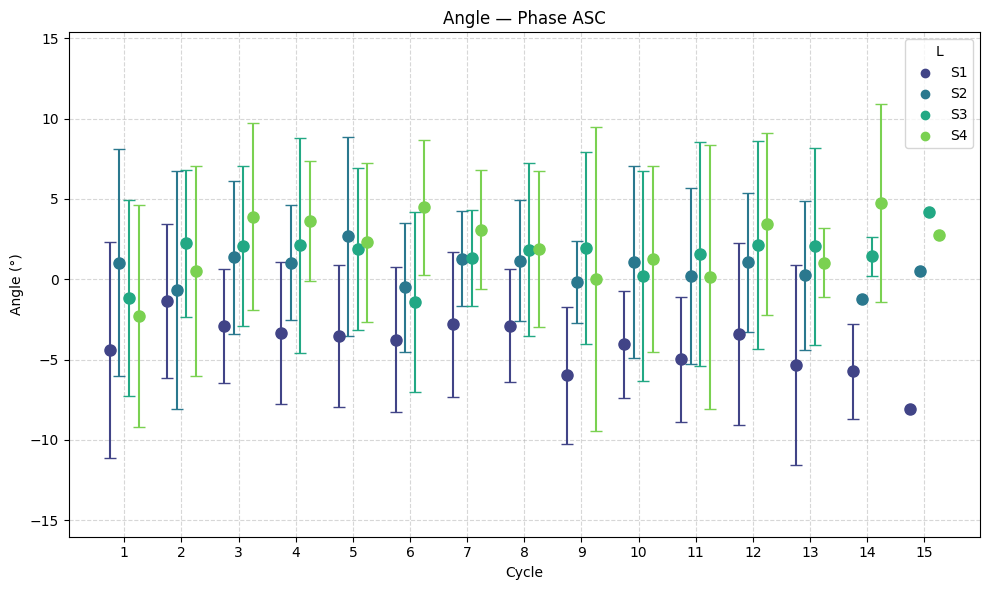

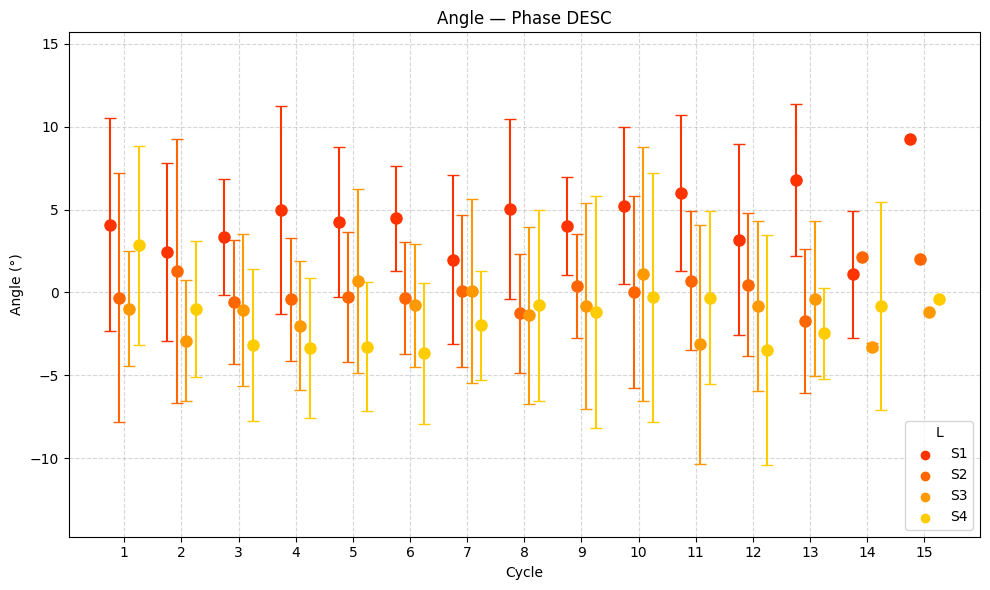

In [30]:
plot_grouped_stats(df_stats_all, measure="angle")

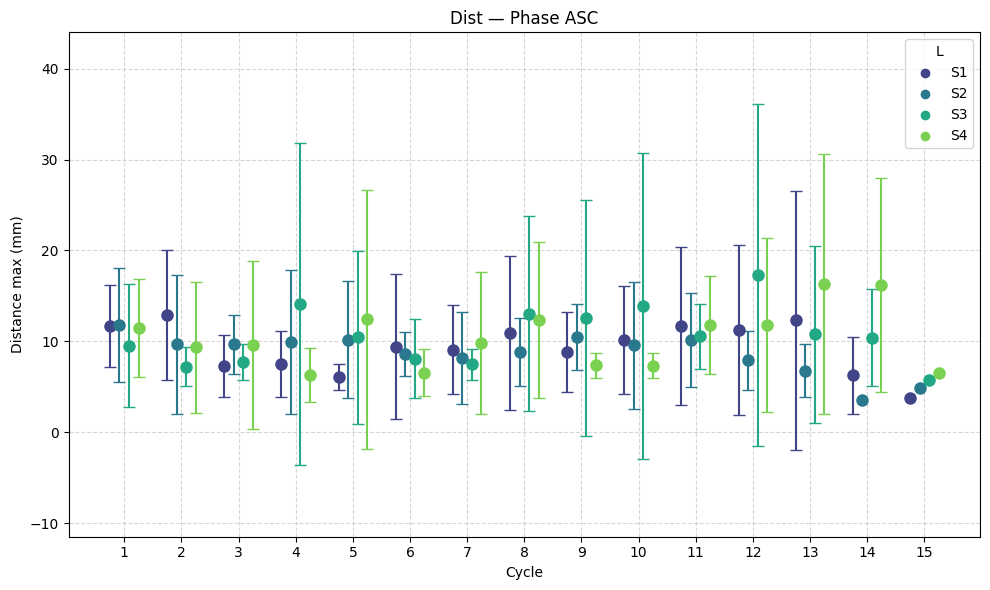

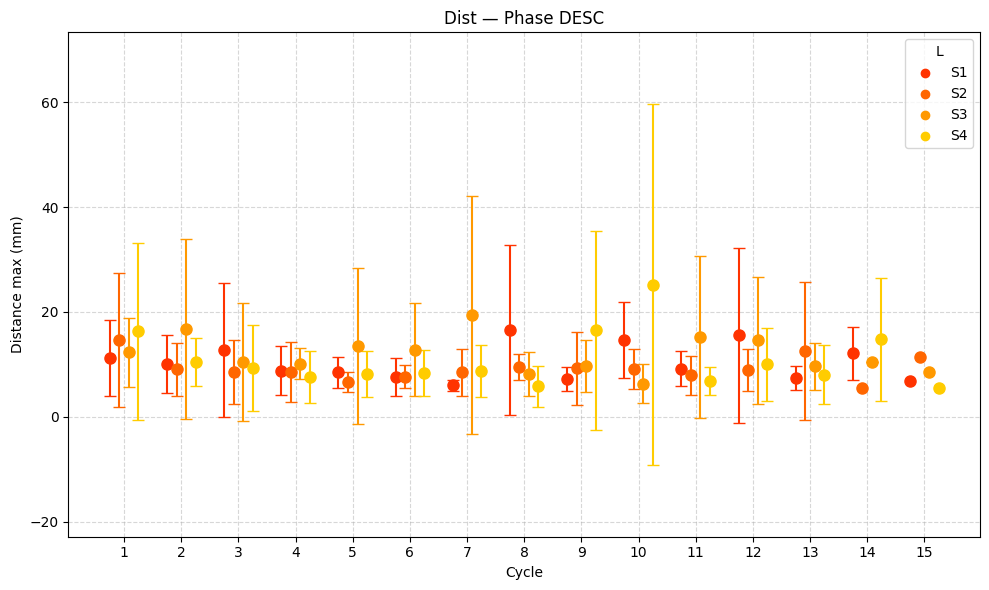

In [31]:
plot_grouped_stats(df_stats_all, measure="dist")

In [34]:
warnings.filterwarnings("ignore")

def plot_stats_global(df_stats_all, measure="angle"):
    
    S_order = ["S1","S2","S3","S4"]
    
    phase_colors = {
        "ASC": cm.viridis(np.linspace(0.2,0.8,len(S_order))),
        "DESC": cm.autumn(np.linspace(0.2,0.8,len(S_order)))
    }
    
    alpha = 0.1
    n_comparisons = len(S_order) - 1
    alpha_corr = alpha / n_comparisons

    fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)
    phases = df_stats_all["phase"].unique()

    for ax, phase in zip(axes, phases):

        df_phase = df_stats_all[df_stats_all["phase"] == phase]

        # ========================
        # 🔹 FOND : SPAGHETTI SUJETS
        # ========================
        for subject in df_phase["subject"].unique():

            df_sub = df_phase[df_phase["subject"] == subject]

            # 🔥 MOYENNE PAR SUJET × CONDITION (FIX BUG)
            df_sub = df_sub.groupby("S").agg(
                mean_val=(f"{measure}_mean", "mean")
            ).reset_index()

            # ordre L1 → L4
            df_sub = df_sub.set_index("S").reindex(S_order).reset_index()

            x_vals = np.arange(len(S_order))
            y_vals = df_sub["mean_val"].values

            if np.all(np.isnan(y_vals)):
                continue

            # ligne
            ax.plot(x_vals, y_vals,
                    color="gray", alpha=0.25, linewidth=1, zorder=1)

            # points
            ax.scatter(x_vals, y_vals,
                       color="gray", alpha=0.4, s=25, zorder=2)

        # ========================
        # 🔹 MOYENNE INTER-SUJETS
        # ========================
        df_grouped = df_phase.groupby("S").agg(
            mean_val=(f"{measure}_mean", "mean"),
            std_val=(f"{measure}_mean", "std"),
            n=(f"{measure}_mean", "count")
        ).reset_index()

        df_grouped["std_err"] = df_grouped["std_val"] / np.sqrt(df_grouped["n"])

        for i, S in enumerate(S_order):

            row = df_grouped[df_grouped["S"] == S]
            if row.empty:
                continue

            mean_val = row["mean_val"].values[0]
            std_err = row["std_err"].values[0]
            color = phase_colors[phase][i]

            # moyenne + erreur
            ax.errorbar(i, mean_val, yerr=std_err, fmt='o',
                        color=color, capsize=5, markersize=10, zorder=3)

            # ========================
            # 🔹 T-TEST vs S1
            # ========================
            if S != "S1":

                data_S = df_phase[df_phase["S"] == S][f"{measure}_mean"].values
                data_S1 = df_phase[df_phase["S"] == "S1"][f"{measure}_mean"].values

                try:
                    t_stat, p_val = ttest_ind(data_S, data_S1, equal_var=False)

                    if p_val < alpha_corr:

                        star = "**"
                        offset = 0.5 if measure == "angle" else 0.2

                        ax.text(i, mean_val + std_err + offset, star,
                                ha="center", va="bottom",
                                fontsize=14, fontweight="bold")

                        print(f"{measure.upper()} | {phase} | {S} vs S1 : p={p_val:.4f}")

                except:
                    pass

        # ========================
        # 🔹 STYLE
        # ========================
        ax.set_title(f"{measure.capitalize()} — Phase {phase}")
        ax.set_xticks(range(len(S_order)))
        ax.set_xticklabels(S_order)
        ax.set_ylabel("Angle (°)" if measure=="angle" else "Distance max (mm)")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.margins(y=0.2)

    plt.suptitle(f"{measure.capitalize()} — multi-sujets (t-test + Bonferroni)")
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

ANGLE | ASC | S2 vs S1 : p=0.0000
ANGLE | ASC | S3 vs S1 : p=0.0000
ANGLE | ASC | S4 vs S1 : p=0.0000
ANGLE | DESC | S2 vs S1 : p=0.0000
ANGLE | DESC | S3 vs S1 : p=0.0000
ANGLE | DESC | S4 vs S1 : p=0.0000


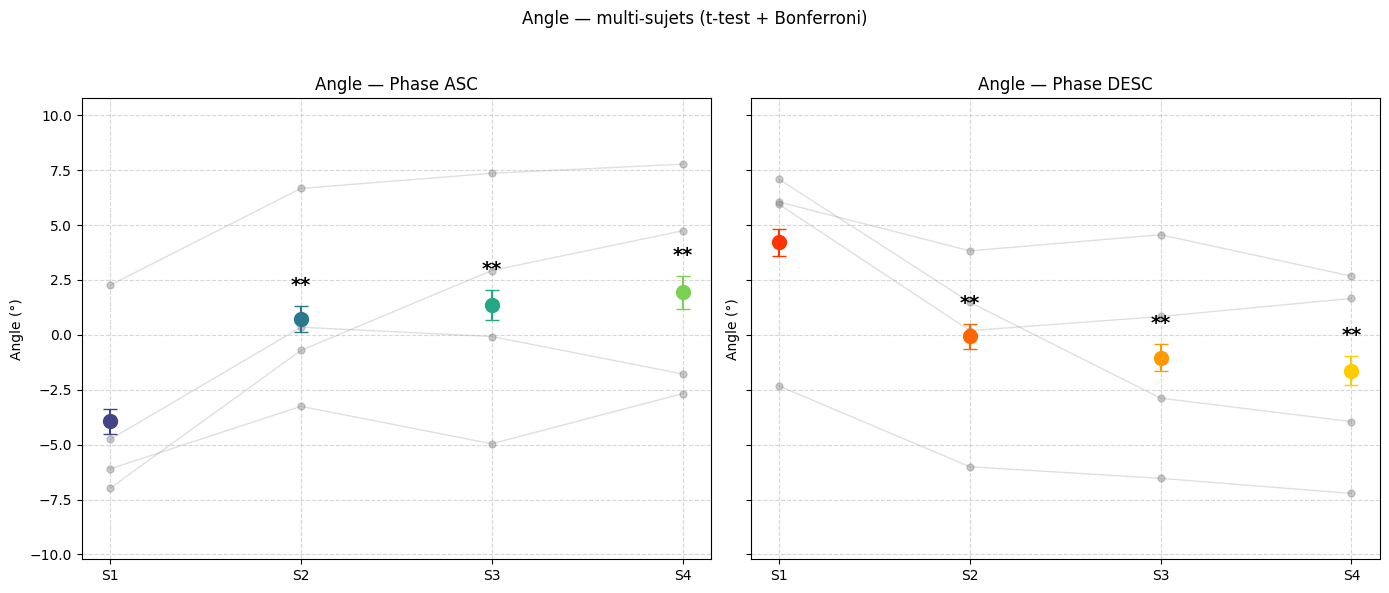

In [35]:
plot_stats_global(df_stats_all, measure="angle")

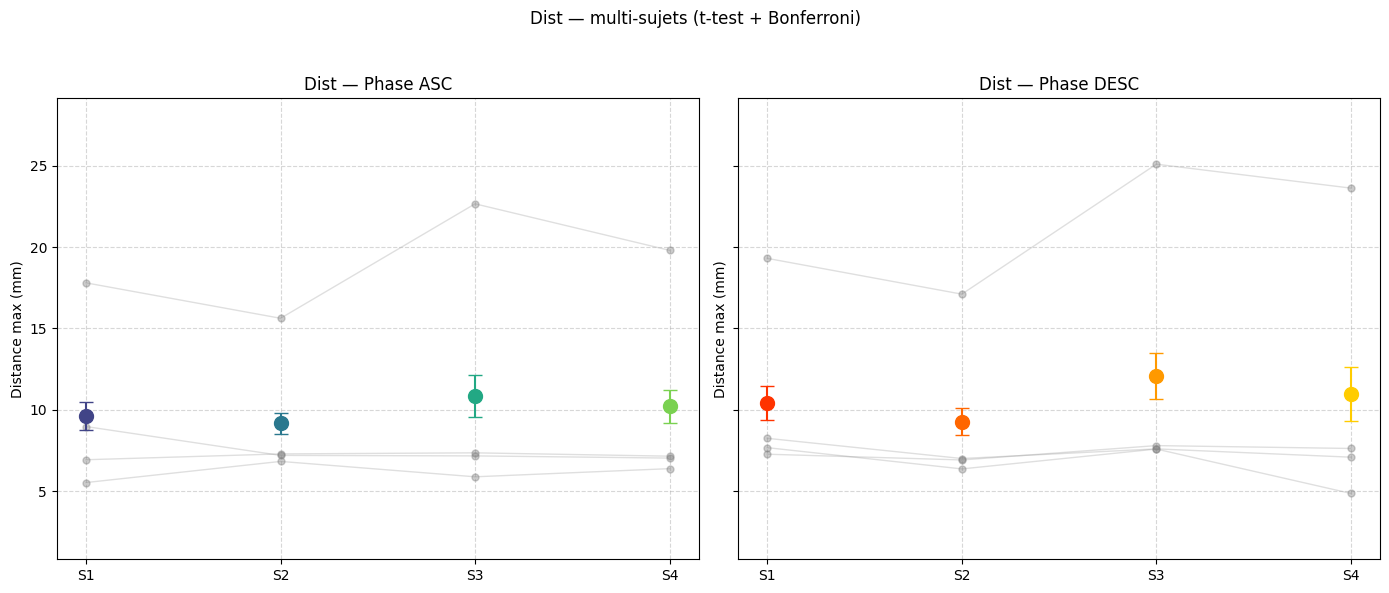

In [36]:
plot_stats_global(df_stats_all, measure="dist")

In [37]:
def compute_velocities(df_pos, h, time_col="Time"):
    """
    Calcule les vitesses pour toutes les colonnes d'un DataFrame de positions
    en utilisant une dérivée centrée d'ordre 4.
    
    Parameters
    ----------
    df_pos : DataFrame
        DataFrame contenant Time + positions
    h : float
        pas de temps (ex: 1/200)
    time_col : str
        nom de la colonne temps
        
    Returns
    -------
    velocities : DataFrame
    """

    def vitesse_centre(U, h):
        U = np.asarray(U, dtype=float)
        N = len(U)
        V = np.zeros_like(U)

        if N < 5:
            # fallback simple si trop court
            V[1:] = np.diff(U) / h
            V[0] = V[1]
            return V

        # bords
        V[0] = (U[1] - U[0]) / h
        V[1] = (U[2] - U[1]) / h

        # cœur (vectorisé 🔥)
        V[2:-2] = (-U[4:] + 8*U[3:-1] - 8*U[1:-3] + U[0:-4]) / (12*h)

        # fin
        V[-2] = (U[-2] - U[-3]) / h
        V[-1] = (U[-1] - U[-2]) / h

        return V

    velocities = pd.DataFrame()
    velocities[time_col] = df_pos[time_col]

    cols = [c for c in df_pos.columns if c != time_col]

    for col in cols:
        velocities[col] = vitesse_centre(df_pos[col].values, h)

    print("✅ Vitesses calculées :", len(cols), "signaux")

    return velocities

In [38]:
def compute_speed_profiles_and_rtpv(
    velocities,
    minima_times_df,
    maxima_times_df,
    subject="S01",
    n_points=200
):

    time_col = "Time"
    t_norm = np.linspace(0, 1, n_points)

    bases = sorted(set([c.rsplit("_",1)[0] for c in velocities.columns if c != time_col]))

    def extract_S(name):
        m = re.search(r"(S[1-4])(?!\d)", name)
        return m.group(1) if m else "UNKNOWN"

    def compute_peak_percent(curve):
        idx = np.argmax(curve)
        return idx / len(curve) * 100

    data_up = {S: [] for S in ["S1","S2","S3","S4"]}
    data_down = {S: [] for S in ["S1","S2","S3","S4"]}

    rtpv_records = []

    time_vals = velocities[time_col].values

    for base in bases:

        col_x = f"{base}_X"
        col_y = f"{base}_Y"
        col_z = f"{base}_Z"

        if not all(c in velocities.columns for c in [col_x, col_y, col_z]):
            continue

        col_ref = col_y

        if col_ref not in minima_times_df.columns or col_ref not in maxima_times_df.columns:
            continue

        S = extract_S(base)
        if S not in data_up:
            continue

        minima_times = minima_times_df[col_ref].dropna().values
        maxima_times = maxima_times_df[col_ref].dropna().values

        vx = velocities[col_x].values
        vy = velocities[col_y].values
        vz = velocities[col_z].values

        speed = np.sqrt(vx**2 + vy**2 + vz**2)

        # ========================
        # ASC
        # ========================
        for t_min in minima_times:

            max_after = maxima_times[maxima_times > t_min]
            if len(max_after) == 0:
                continue

            t_max = max_after[0]

            mask = (time_vals >= t_min) & (time_vals <= t_max)
            seg_t = time_vals[mask]
            seg_v = speed[mask]

            if len(seg_t) < 10:
                continue

            t_scaled = (seg_t - seg_t[0]) / (seg_t[-1] - seg_t[0])
            v_interp = np.interp(t_norm, t_scaled, seg_v)

            data_up[S].append(v_interp)

            rtpv_records.append({
                "subject": subject,
                "S": S,
                "phase": "ASC",
                "rtpv": compute_peak_percent(v_interp)
            })

        # ========================
        # DESC
        # ========================
        for t_max in maxima_times:

            min_after = minima_times[minima_times > t_max]
            if len(min_after) == 0:
                continue

            t_min = min_after[0]

            mask = (time_vals >= t_max) & (time_vals <= t_min)
            seg_t = time_vals[mask]
            seg_v = speed[mask]

            if len(seg_t) < 10:
                continue

            t_scaled = (seg_t - seg_t[0]) / (seg_t[-1] - seg_t[0])
            v_interp = np.interp(t_norm, t_scaled, seg_v)

            data_down[S].append(v_interp)

            rtpv_records.append({
                "subject": subject,
                "S": S,
                "phase": "DESC",
                "rtpv": compute_peak_percent(v_interp)
            })

    df_rtpv = pd.DataFrame(rtpv_records)

    return data_up, data_down, df_rtpv, t_norm

In [39]:
velocities_dict = {}
df_final_dict = {
    "S01": finus_1,
    "S02": finus_2,
    "S03": finus_3,
    "S04": finus_4
}

for subject, df_pos in df_final_dict.items():

    velocities_dict[subject] = compute_velocities(df_pos, h)

print("✅ Toutes les vitesses multi-sujets calculées")


minima_times_dict = {}
maxima_times_dict = {}

for subject, df_subject in df_final_dict.items(): 
    
    minima_records = {}
    maxima_records = {}
    
    y_cols = [c for c in df_subject.columns if c.endswith("_Y")]
    
    for col in y_cols:
        y = df_subject[col].values
        t = df_subject["Time"].values
        
        min_idx = (np.r_[True, y[1:] < y[:-1]] & np.r_[y[:-1] < y[1:], True])
        minima_records[col] = t[min_idx]
        
        max_idx = (np.r_[True, y[1:] > y[:-1]] & np.r_[y[:-1] > y[1:], True])
        maxima_records[col] = t[max_idx]
    
    minima_times_dict[subject] = pd.DataFrame({k: pd.Series(v) for k, v in minima_records.items()})
    maxima_times_dict[subject] = pd.DataFrame({k: pd.Series(v) for k, v in maxima_records.items()})

print("✅ Minima/maxima multi-sujets extraits")

✅ Vitesses calculées : 48 signaux
✅ Vitesses calculées : 48 signaux
✅ Vitesses calculées : 36 signaux
✅ Vitesses calculées : 36 signaux
✅ Toutes les vitesses multi-sujets calculées
✅ Minima/maxima multi-sujets extraits


In [40]:
all_up = {S: [] for S in ["S1","S2","S3","S4"]}
all_down = {S: [] for S in ["S1","S2","S3","S4"]}
df_rtpv_all = []

for subject, velocities in velocities_dict.items():

    data_up, data_down, df_rtpv, t_norm = compute_speed_profiles_and_rtpv(
        velocities,
        minima_times_dict[subject],
        maxima_times_dict[subject],
        subject=subject
    )

    for S in all_up:
        all_up[S].extend(data_up[S])
        all_down[S].extend(data_down[S])

    df_rtpv_all.append(df_rtpv)

df_rtpv_all = pd.concat(df_rtpv_all, ignore_index=True)

In [43]:
def plot_global_speed(all_data, t_norm, phase_name):
    plt.figure(figsize=(10,5))

    # palette pour chaque L
    S_order = ["S1","S2","S3","S4"]
    colors = cm.tab10(np.linspace(0, 1, len(S_order)))

    for i, S in enumerate(S_order):
        curves = np.array(all_data[S])
        if len(curves) == 0: 
            continue

        mean_curve = np.mean(curves, axis=0)
        std_curve = np.std(curves, axis=0)
        color = colors[i]

        # plot ligne
        plt.plot(t_norm, mean_curve, label=S, color=color)

        # plot bande ± std avec même couleur et transparence
        plt.fill_between(
            t_norm,
            mean_curve - std_curve,
            mean_curve + std_curve,
            color=color,
            alpha=0.3
        )

    plt.title(f"Norme vitesse moyenne ± std — {phase_name} (multi-sujets)")
    plt.xlabel("Temps normalisé")
    plt.ylabel("Vitesse (norme 3D)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

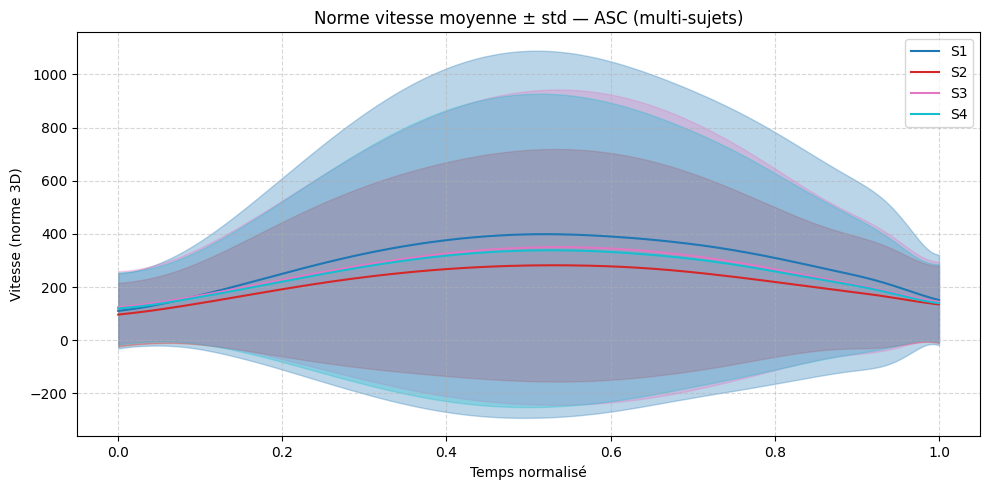

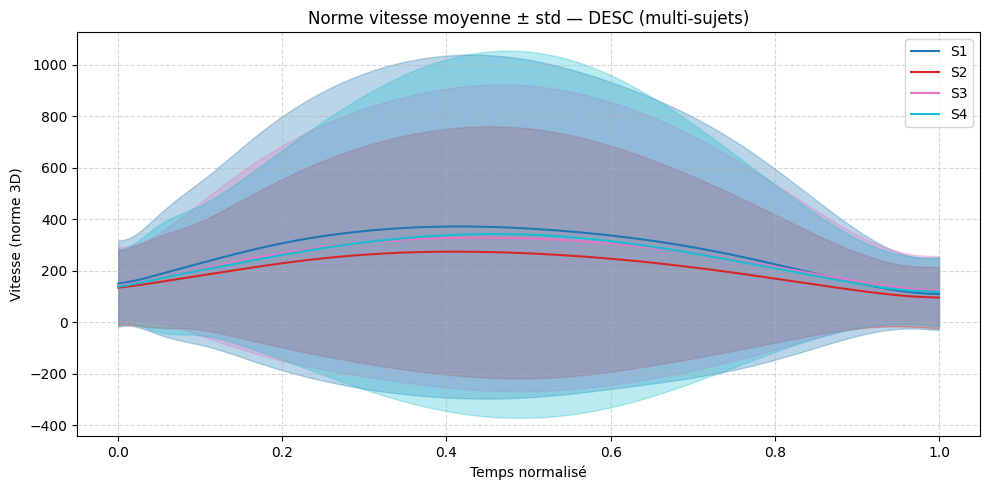

In [44]:
plot_global_speed(all_up, t_norm, "ASC")
plot_global_speed(all_down, t_norm, "DESC")

In [50]:
warnings.filterwarnings("ignore")

def compute_rtpv_stats(velocities_dict, minima_times_dict, maxima_times_dict, n_points=200):
    
    t_norm = np.linspace(0, 1, n_points)
    S_levels = ["S1", "S2", "S3", "S4"]
    
    all_curves_up = {S: [] for S in S_levels}
    all_curves_down = {S: [] for S in S_levels}
    rtpv_records = []
    
    def extract_S(name):
        m = re.search(r"(S[1-4])(?!\d)", name)
        return m.group(1) if m else None
    
    def compute_peak_percent(curve):
        """Retourne l'indice du pic en % (0-100) du mouvement."""
        idx = np.argmax(np.abs(curve))
        return idx / len(curve) * 100
    
    for subject, velocities in velocities_dict.items():
        time_col = "Time"
        time_vals = velocities[time_col].values
        
        minima_df = minima_times_dict[subject]
        maxima_df = maxima_times_dict[subject]
        
        # Trouver les bases (marqueurs) disponibles
        bases = sorted(set([
            c.rsplit("_", 1)[0] 
            for c in velocities.columns 
            if c != time_col and "_" in c
        ]))
        
        for base in bases:
            col_x = f"{base}_X"
            col_y = f"{base}_Y"
            col_z = f"{base}_Z"
            
            # Vérifier colonnes vitesse
            available_cols = [c for c in [col_x, col_y, col_z] if c in velocities.columns]
            if len(available_cols) == 0:
                continue
            
            # Colonne de référence pour min/max
            col_ref = col_y if col_y in velocities.columns else available_cols[0]
            
            if col_ref not in minima_df.columns or col_ref not in maxima_df.columns:
                continue
            
            S = extract_S(base)
            if S not in S_levels:
                continue
            
            minima_times = minima_df[col_ref].dropna().values
            maxima_times = maxima_df[col_ref].dropna().values
            
            # Calcul de la norme de vitesse 3D (ou 2D/1D selon dispo)
            if all(c in velocities.columns for c in [col_x, col_y, col_z]):
                speed = np.sqrt(
                    velocities[col_x].values**2 + 
                    velocities[col_y].values**2 + 
                    velocities[col_z].values**2
                )
            elif col_x in velocities.columns and col_y in velocities.columns:
                speed = np.sqrt(
                    velocities[col_x].values**2 + 
                    velocities[col_y].values**2
                )
            else:
                speed = np.abs(velocities[col_ref].values)
            
            # ===== ASC (min → max) =====
            for t_min in minima_times:
                max_after = maxima_times[maxima_times > t_min]
                if len(max_after) == 0:
                    continue
                t_max = max_after[0]
                
                mask = (time_vals >= t_min) & (time_vals <= t_max)
                seg_t = time_vals[mask]
                seg_v = speed[mask]
                
                if len(seg_t) < 10:
                    continue
                
                t_scaled = (seg_t - seg_t[0]) / (seg_t[-1] - seg_t[0])
                v_interp = np.interp(t_norm, t_scaled, seg_v)
                
                all_curves_up[S].append(v_interp)
                rtpv_records.append({
                    "subject": subject,
                    "S": S,
                    "phase": "ASC",
                    "rtpv": compute_peak_percent(v_interp)
                })
            
            # ===== DESC (max → min) =====
            for t_max in maxima_times:
                min_after = minima_times[minima_times > t_max]
                if len(min_after) == 0:
                    continue
                t_min = min_after[0]
                
                mask = (time_vals >= t_max) & (time_vals <= t_min)
                seg_t = time_vals[mask]
                seg_v = speed[mask]
                
                if len(seg_t) < 10:
                    continue
                
                t_scaled = (seg_t - seg_t[0]) / (seg_t[-1] - seg_t[0])
                v_interp = np.interp(t_norm, t_scaled, seg_v)
                
                all_curves_down[S].append(v_interp)
                rtpv_records.append({
                    "subject": subject,
                    "S": S,
                    "phase": "DESC",
                    "rtpv": compute_peak_percent(v_interp)
                })
    
    df_rtpv = pd.DataFrame(rtpv_records)
    
    return df_rtpv, all_curves_up, all_curves_down, t_norm

In [51]:
def compute_rtpv_statistics(df_rtpv, alpha=0.05):
  
    S_order = ["S1", "S2", "S3", "S4"]
    phases = ["ASC", "DESC"]
    n_comparisons = len(S_order) - 1
    
    # Résumé descriptif
    df_summary = df_rtpv.groupby(["S", "phase"]).agg(
        mean_percent=("rtpv", "mean"),
        std_percent=("rtpv", "std"),
        n=("rtpv", "count")
    ).reset_index()
    
    # ANOVA par phase
    anova_results = {}
    for phase in phases:
        df_phase = df_rtpv[df_rtpv["phase"] == phase]
        groups = [
            df_phase[df_phase["S"] == S]["rtpv"].values 
            for L in S_order 
            if len(df_phase[df_phase["S"] == S]) > 0
        ]
        if len(groups) >= 2:
            f_val, p_val = stats.f_oneway(*groups)
            anova_results[phase] = p_val
        else:
            anova_results[phase] = np.nan
    
    # T-tests vs S1 (Bonferroni)
    ttest_results = {}
    for phase in phases:
        df_phase = df_rtpv[df_rtpv["phase"] == phase]
        S1_vals = df_phase[df_phase["S"] == "S1"]["rtpv"].values
        ttest_results[phase] = {}
        
        for S in ["S2", "S3", "S4"]:
            S_vals = df_phase[df_phase["S"] == S]["rtpv"].values
            if len(S1_vals) > 1 and len(S_vals) > 1:
                t_stat, p_val = stats.ttest_ind(S1_vals, S_vals, equal_var=False)
                p_corr = min(p_val * n_comparisons, 1.0)
            else:
                p_corr = np.nan
            ttest_results[phase][S] = p_corr
    
    return df_summary, anova_results, ttest_results

In [52]:
def plot_rtpv_anova(df_summary, anova_results):
    """Plot RTPV avec résultats ANOVA."""
    
    S_order = ["S1", "S2", "S3", "S4"]
    phases = ["ASC", "DESC"]
    colors = {"ASC": "tab:blue", "DESC": "tab:orange"}
    offsets = {"ASC": -0.1, "DESC": 0.1}
    
    fig, ax = plt.subplots(figsize=(9, 5))
    x_base = np.arange(len(S_order))

    for phase in phases:

        df_phase = df_stats_all[df_stats_all["phase"] == phase]

        # ========================
        # 🔹 FOND : SPAGHETTI SUJETS
        # ========================
        for subject in df_phase["subject"].unique():

            df_sub = df_phase[df_phase["subject"] == subject]

            # 🔥 MOYENNE PAR SUJET × CONDITION (FIX BUG)
            df_sub = df_sub.groupby("S").agg(
                mean_val=(f"{measure}_mean", "mean")
            ).reset_index()

            # ordre S1 → S4
            df_sub = df_sub.set_index("S").reindex(S_order).reset_index()

            x_vals = np.arange(len(S_order))
            y_vals = df_sub["mean_val"].values

            if np.all(np.isnan(y_vals)):
                continue

            # ligne
            ax.plot(x_vals, y_vals,
                    color="gray", alpha=0.25, linewidth=1, zorder=1)

            # points
            ax.scatter(x_vals, y_vals,
                       color="gray", alpha=0.4, s=25, zorder=2)
    
    for phase in phases:
        df_phase = df_summary[df_summary["phase"] == phase].set_index("S").reindex(S_order)
        offset = offsets[phase]
        x_vals = x_base + offset
        
        p_val = anova_results.get(phase, np.nan)
        sig = "**"
        label = f"{phase} {(sig)}" if not np.isnan(p_val) else phase
        
        ax.errorbar(
            x_vals,
            df_phase["mean_percent"].values,
            yerr=df_phase["std_percent"].values,
            fmt='o-',
            capsize=5,
            color=colors[phase],
            label=label
        )
    
    ax.set_xticks(x_base)
    ax.set_xticklabels(S_order)
    ax.set_xlabel("Condition")
    ax.set_ylabel("RTPV (%)")
    ax.set_title("Relative Time to Peak Velocity — ANOVA")
    ax.legend(loc='upper right')
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [53]:
df_stats_all = pd.concat(all_stats, ignore_index=True)
print(df_stats_all.head())

  subject   S  cycle_clean phase  angle_mean  angle_std  dist_mean  dist_std
0     S01  S1            1   ASC  -11.941951  13.171891   6.754096  4.010573
1     S01  S1            1  DESC    7.018053   6.344366   7.783739  4.903894
2     S01  S1            2   ASC   -4.823952   2.556539   8.503773  2.431541
3     S01  S1            2  DESC    6.859128   4.384025   9.047388  3.244781
4     S01  S1            3   ASC   -4.229451   3.525701   6.193812  4.024474


In [55]:
def compute_rtpv_statistics_per_subject(df_rtpv):
    # Groupby par sujet, L et phase
    df_summary_subject = df_rtpv.groupby(["subject", "S", "phase"]).agg(
        mean_percent=("rtpv", "mean"),
        std_percent=("rtpv", "std"),
        n=("rtpv", "count")
    ).reset_index()
    
    return df_summary_subject

In [58]:
# Données existantes
df_final_dict = {
    "S01": finus_1,
    "S02": finus_2,
    "S03": finus_3,
    "S04": finus_4
}

# 1. Calcul des vitesses (si flemme de run tout le code)
h = 1/200  # ton pas de temps
velocities_dict = {}
for subject, df_pos in df_final_dict.items():
    velocities_dict[subject] = compute_velocities(df_pos, h)

# 2. Extraction min/max (idem)
minima_times_dict = {}
maxima_times_dict = {}
t_min = 7
t_max = 43
for subject, df_subject in df_final_dict.items():
    minima_df, maxima_df = detect_min_max(df_subject, t_min, t_max,distance=200, prominence=5, time_col="Time")
    minima_times_dict[subject] = minima_df
    maxima_times_dict[subject] = maxima_df

# 3. Calcul RTPV
df_rtpv, all_curves_up, all_curves_down, t_norm = compute_rtpv_stats(
    velocities_dict, 
    minima_times_dict, 
    maxima_times_dict
)
# 4. Stats
df_summary = compute_rtpv_statistics_per_subject(df_rtpv)

# 5. Affichage
print("=" * 50)
print("RÉSUMÉ DESCRIPTIF")
print("=" * 50)
print(df_summary.to_string(index=False))

✅ Vitesses calculées : 48 signaux
✅ Vitesses calculées : 48 signaux
✅ Vitesses calculées : 36 signaux
✅ Vitesses calculées : 36 signaux
RÉSUMÉ DESCRIPTIF
subject  S phase  mean_percent  std_percent  n
    S01 S1   ASC     51.991935    17.362691 62
    S01 S1  DESC     45.741935    20.131686 62
    S01 S2   ASC     54.065574    18.684101 61
    S01 S2  DESC     41.310345    21.631448 58
    S01 S3   ASC     48.098361    17.108434 61
    S01 S3  DESC     36.100000    21.788233 60
    S01 S4   ASC     50.194915    26.183539 59
    S01 S4  DESC     32.758333    24.078173 60
    S02 S1   ASC     65.114754    28.997039 61
    S02 S1  DESC     23.883929    17.314731 56
    S02 S2   ASC     51.877193    31.544651 57
    S02 S2  DESC     24.452830    22.092303 53
    S02 S3   ASC     68.875000    30.097529 60
    S02 S3  DESC     18.598214    23.951735 56
    S02 S4   ASC     72.923729    27.690222 59
    S02 S4  DESC     13.250000    13.682770 56
    S03 S1   ASC     51.000000    25.071042 36


In [59]:
def plot_rtpv_per_subject_and_mean(df_summary, S_order=["S1","S2","S3","S4"]):
    """
    Plot RTPV avec :
    1) spaghetti sujets en gris clair
    2) moyenne ± std sur tous les sujets
    3) ANOVA sur la moyenne, signif dans la légende
    4) 2 graphes : ASC et DESC
    """

    phases = ["ASC", "DESC"]
    colors = {"ASC": "tab:blue", "DESC": "tab:orange"}

    for phase in phases:
        df_phase = df_summary[df_summary["phase"] == phase]
        fig, ax = plt.subplots(figsize=(9,5))
        x_base = np.arange(len(S_order))

        # 1) Plot spaghetti par sujet
        subjects = df_phase["subject"].unique()
        jitter = 0.08
        for subj in subjects:
            df_sub = df_phase[df_phase["subject"] == subj].set_index("S").reindex(S_order)
            y_vals = df_sub["mean_percent"].values
            x_jittered = x_base + np.random.uniform(-jitter, jitter, size=len(S_order))
            ax.plot(x_jittered, y_vals, color="gray", alpha=0.3, linewidth=1)
            ax.scatter(x_jittered, y_vals, color="gray", alpha=0.3, s=25)

        # 2) Moyenne ± std sur tous les sujets pour chaque condition
        df_mean = df_phase.groupby("S").agg(
            mean_percent=("mean_percent", "mean"),
            std_percent=("mean_percent", "std"),
            n=("mean_percent", "count")
        ).reindex(S_order)

        ax.errorbar(
            x_base,
            df_mean["mean_percent"].values,
            yerr=df_mean["std_percent"].values,
            fmt='o-',
            color=colors[phase],
            capsize=5,
            linewidth=2,
            markersize=8,
            label=f"{phase} Mean ± SD"
        )

        # 3) ANOVA sur les moyennes par sujet (L1-L4)
        groups = [df_phase[df_phase["S"]==S]["mean_percent"].values for S in S_order]
        if all(len(g) > 1 for g in groups):
            f_val, p_val = stats.f_oneway(*groups)
            sig = "**" if p_val < 0.1 else ""
            ax.legend(title=f"ANOVA p={p_val:.3f} {sig}")
        else:
            ax.legend()

        ax.set_xticks(x_base)
        ax.set_xticklabels(S_order)
        ax.set_xlabel("Condition")
        ax.set_ylabel("RTPV (%)")
        ax.set_title(f"RTPV — Phase {phase}")
        ax.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

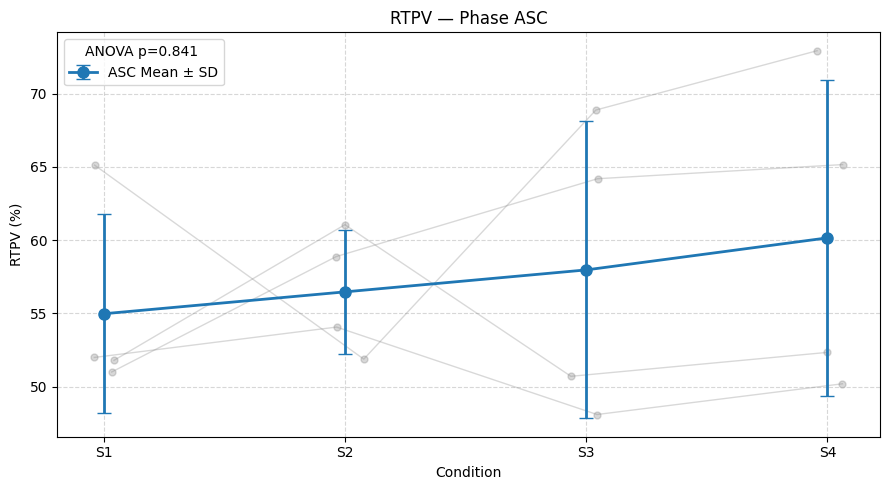

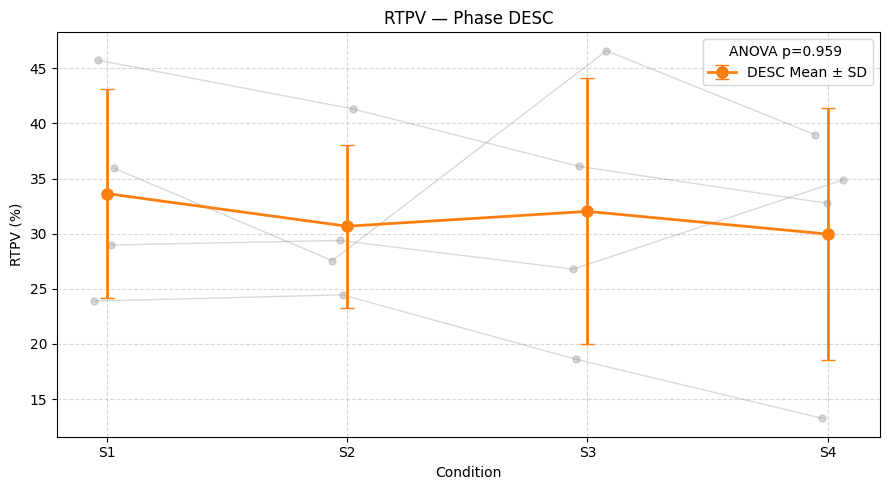

In [60]:
plot_rtpv_per_subject_and_mean(df_summary)

In [64]:
def plot_rtpv_ttests_vs_S1(df_summary, S_order=["S1","S2","S3","S4"], alpha=0.1):

    phases = ["ASC", "DESC"]
    colors = {"ASC": "tab:blue", "DESC": "tab:orange"}
    n_comparisons = len(S_order) - 1  # pour Bonferroni

    for phase in phases:
        df_phase = df_summary[df_summary["phase"] == phase]
        fig, ax = plt.subplots(figsize=(9,5))
        x_base = np.arange(len(S_order))

        # 1) Spaghetti par sujet
        subjects = df_phase["subject"].unique()
        jitter = 0.08
        for subj in subjects:
            df_sub = df_phase[df_phase["subject"] == subj].set_index("S").reindex(S_order)
            y_vals = df_sub["mean_percent"].values
            x_jittered = x_base + np.random.uniform(-jitter, jitter, size=len(S_order))
            ax.plot(x_jittered, y_vals, color="gray", alpha=0.3, linewidth=1)
            ax.scatter(x_jittered, y_vals, color="gray", alpha=0.3, s=25)

        # 2) Moyenne ± std sur tous les sujets
        df_mean = df_phase.groupby("S").agg(
            mean_percent=("mean_percent", "mean"),
            std_percent=("mean_percent", "std"),
            n=("mean_percent", "count")
        ).reindex(S_order)

        ax.errorbar(
            x_base,
            df_mean["mean_percent"].values,
            yerr=df_mean["std_percent"].values,
            fmt='o-',
            color=colors[phase],
            capsize=5,
            linewidth=2,
            markersize=8,
            label=f"{phase} Mean ± SD"
        )

        # 3) T-tests vs S1 avec correction Bonferroni
        S1_vals = df_phase[df_phase["S"]=="S1"]["mean_percent"].values
        def get_star(p):
            if p < 0.1:
                return "**"
            else:
                return None

        for j, S in enumerate(S_order):
            if S == "S1":
                continue
            S_vals = df_phase[df_phase["S"]==S]["mean_percent"].values
            if len(S1_vals) > 1 and len(S_vals) > 1:
                t_stat, p_val = stats.ttest_ind(S1_vals, S_vals, equal_var=False)
                p_corr = min(p_val * n_comparisons, 1.0)  # Bonferroni
                star = get_star(p_corr)
                if star:
                    y_star = df_mean.loc[S,"mean_percent"] + df_mean.loc[S,"std_percent"] + 2
                    ax.text(x_base[j], y_star, star, ha='center', va='bottom',
                            fontsize=14, fontweight='bold', color=colors[phase])

        ax.set_xticks(x_base)
        ax.set_xticklabels(S_order)
        ax.set_xlabel("Condition")
        ax.set_ylabel("RTPV (%)")
        ax.set_title(f"RTPV — Phase {phase} — T-test vs S1")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

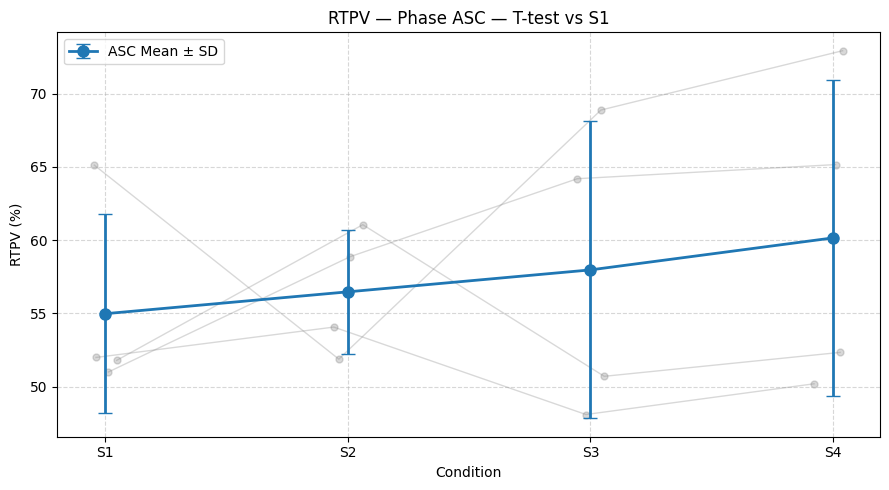

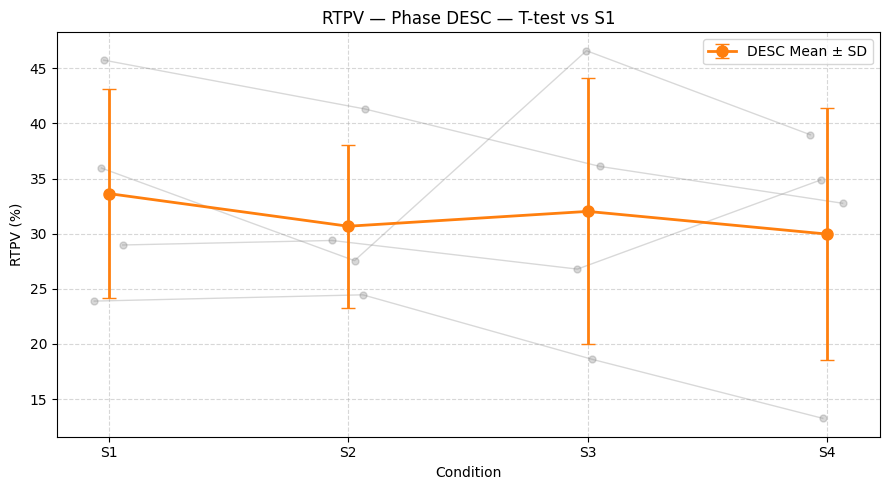

In [65]:
plot_rtpv_ttests_vs_S1(df_summary)

In [67]:
def plot_rtpv_ttests_vs_S2(df_summary, S_order=["S2","S3","S4"], alpha=0.05):

    phases = ["ASC", "DESC"]
    colors = {"ASC": "tab:blue", "DESC": "tab:orange"}
    n_comparisons = len(S_order) - 1  # pour Bonferroni

    for phase in phases:
        df_phase = df_summary[df_summary["phase"] == phase]
        fig, ax = plt.subplots(figsize=(9,5))
        x_base = np.arange(len(S_order))

        # 1) Spaghetti par sujet
        subjects = df_phase["subject"].unique()
        jitter = 0.08
        for subj in subjects:
            df_sub = df_phase[df_phase["subject"] == subj].set_index("S").reindex(S_order)
            y_vals = df_sub["mean_percent"].values
            x_jittered = x_base + np.random.uniform(-jitter, jitter, size=len(S_order))
            ax.plot(x_jittered, y_vals, color="gray", alpha=0.3, linewidth=1)
            ax.scatter(x_jittered, y_vals, color="gray", alpha=0.3, s=25)

        # 2) Moyenne ± std sur tous les sujets
        df_mean = df_phase[df_phase["S"].isin(S_order)].groupby("S").agg(
            mean_percent=("mean_percent", "mean"),
            std_percent=("mean_percent", "std"),
            n=("mean_percent", "count")
        ).reindex(S_order)

        ax.errorbar(
            x_base,
            df_mean["mean_percent"].values,
            yerr=df_mean["std_percent"].values,
            fmt='o-',
            color=colors[phase],
            capsize=5,
            linewidth=2,
            markersize=8,
            label=f"{phase} Mean ± SD"
        )

        # 3) T-tests vs S2 avec correction Bonferroni
        S2_vals = df_phase[df_phase["S"]=="S2"]["mean_percent"].values
        def get_star(p):
            if p < 0.1:
                return "**"
            else:
                return None

        for j, S in enumerate(S_order):
            if S == "S2":
                continue
            S_vals = df_phase[df_phase["S"]==S]["mean_percent"].values
            if len(S2_vals) > 1 and len(S_vals) > 1:
                t_stat, p_val = stats.ttest_ind(S2_vals, S_vals, equal_var=False)
                p_corr = min(p_val * n_comparisons, 1.0)  # Bonferroni
                star = get_star(p_corr)
                if star:
                    y_star = df_mean.loc[S,"mean_percent"] + df_mean.loc[S,"std_percent"] + 2
                    ax.text(x_base[j], y_star, star, ha='center', va='bottom',
                            fontsize=14, fontweight='bold', color=colors[phase])

        ax.set_xticks(x_base)
        ax.set_xticklabels(S_order)
        ax.set_xlabel("Condition")
        ax.set_ylabel("RTPV (%)")
        ax.set_title(f"RTPV — Phase {phase} — T-test vs S2")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

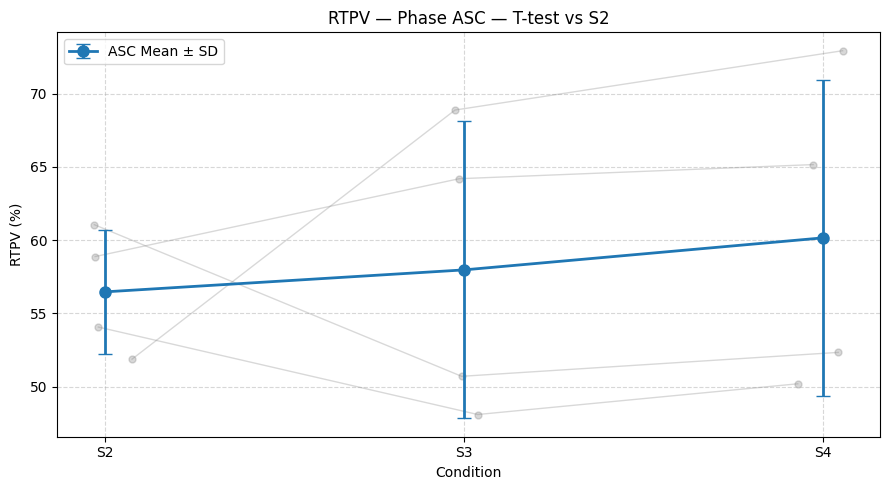

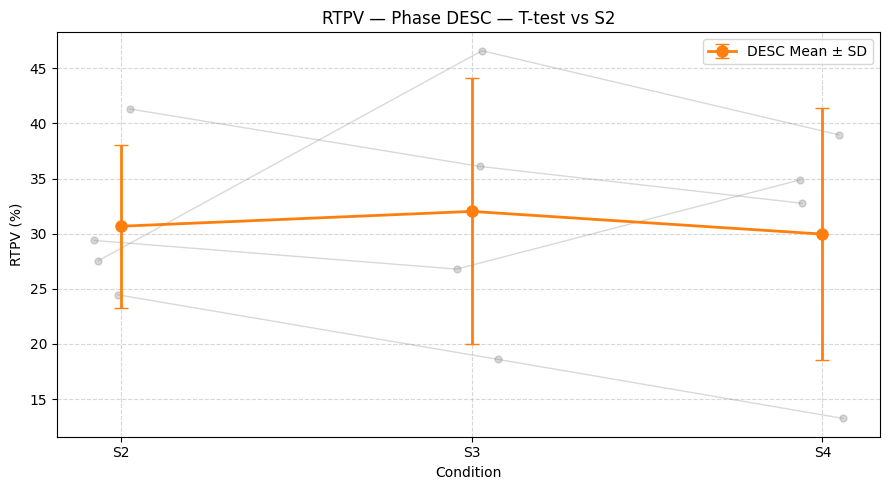

In [68]:
plot_rtpv_ttests_vs_S2(df_summary)